### 1.1.2 解决问题

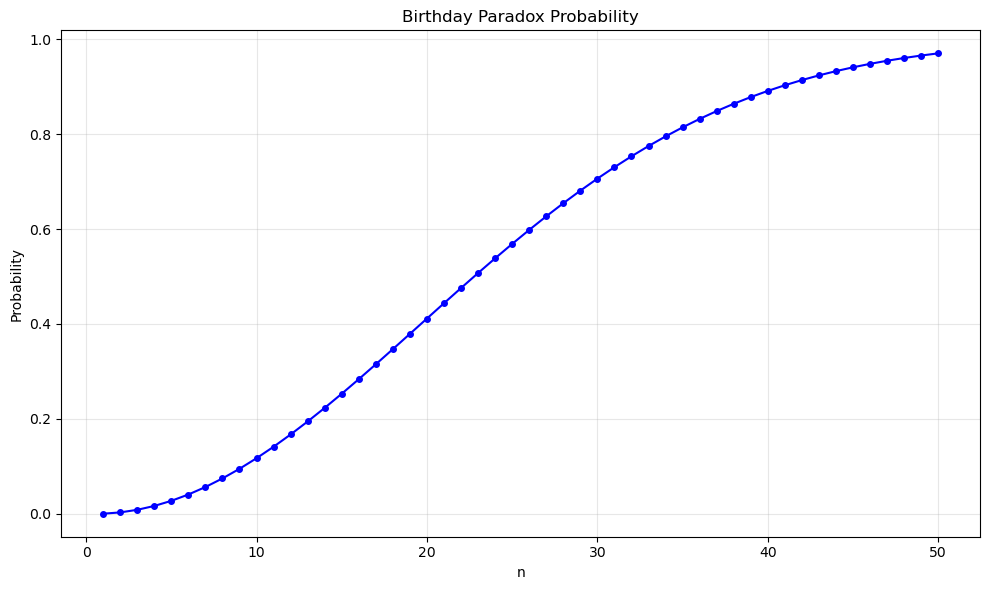

前10个值:
n=1: 生日在同一天的概率 = 0.000000
n=2: 生日在同一天的概率 = 0.002740
n=3: 生日在同一天的概率 = 0.008204
n=4: 生日在同一天的概率 = 0.016356
n=5: 生日在同一天的概率 = 0.027136
n=6: 生日在同一天的概率 = 0.040462
n=7: 生日在同一天的概率 = 0.056236
n=8: 生日在同一天的概率 = 0.074335
n=9: 生日在同一天的概率 = 0.094624
n=10: 生日在同一天的概率 = 0.116948


In [4]:
import matplotlib.pyplot as plt

# 计算生日概率的Python代码

# 初始化"生日在同一天"和"生日不在同一天"的概率列表
# 因为递归计算需要存储之前的值
noshare = [[1, 1]]  # 开始时, 生日不在同一天的概率是100%
share = [[1, 0]]    # 开始时, 生日在同一天的概率是0%
currentnoshare = 1  # 当前生日不在同一天的概率

for n in range(2, 51):  # 将计算前50个人的情况
    # 乘积的第二项
    newfactor = (365 - (n - 1)) / 365
    
    # 更新"生日不在同一天"的概率
    currentnoshare = currentnoshare * newfactor
    
    # 添加到列表
    noshare.append([n, float(currentnoshare)])
    
    # 更新"生日在同一天"的概率
    share.append([n, 1.0 - currentnoshare])

# 提取x和y坐标用于绘图
x_values = [item[0] for item in share]
y_values = [item[1] for item in share]

# 绘制图形
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'b-', marker='o', markersize=4)
plt.xlabel('n')
plt.ylabel('Probability')
plt.title('Birthday Paradox Probability')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 可选：打印前10个值供检查
print("前10个值:")
for i in range(min(10, len(share))):
    print(f"n={share[i][0]}: 生日在同一天的概率 = {share[i][1]:.6f}")

### 1.1.4 数值检验

Observed probability of success with 1/2 + Sqrt[D log(4)] people is 48.10%.


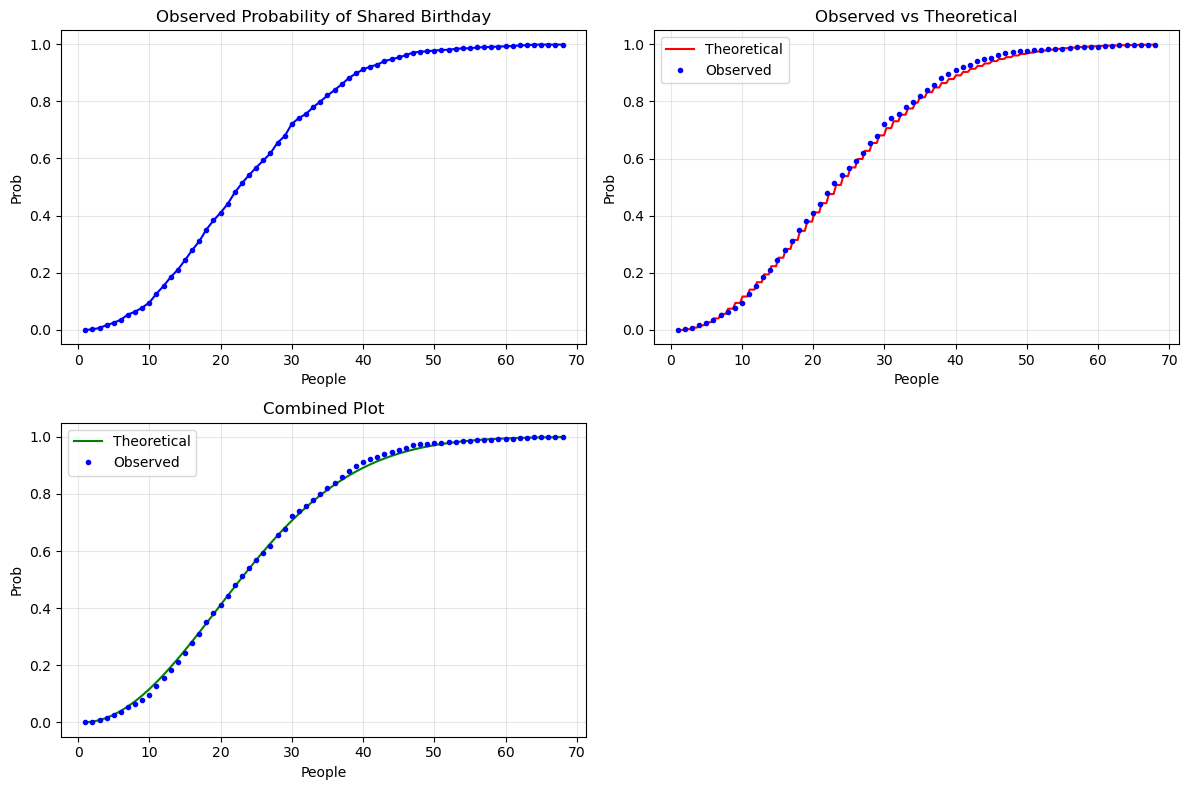


前10个数据点（人数，观察到的概率）：
People =  1, Probability = 0.0000
People =  2, Probability = 0.0020
People =  3, Probability = 0.0070
People =  4, Probability = 0.0170
People =  5, Probability = 0.0250
People =  6, Probability = 0.0360
People =  7, Probability = 0.0540
People =  8, Probability = 0.0640
People =  9, Probability = 0.0780
People = 10, Probability = 0.0960


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import random
from math import sqrt, log, floor

def birthday_cdf(num, days):
    """
    num: 实验次数（模拟的房间数量）
    days: 一年的总天数
    """
    # 初始化 numpeople 数组，索引从0开始，但我们将使用1-based索引
    # 所以创建 days+1 长度的数组，索引0不使用
    numpeople = [0] * (days + 1)
    
    # 对n次实验进行循环
    for n in range(1, num + 1):
        share = 0  # 0表示没有共享生日，1表示有共享生日
        bdaylist = []  # 存储房间里人们的生日
        k = 0  # 房间里的人数
        
        while share == 0:
            # 随机选择一个新的生日（1到days之间）
            x = random.randint(1, days)
            
            # 检查这个生日是否已经在列表中
            if x not in bdaylist:
                bdaylist.append(x)
            else:
                share = 1
            
            k = k + 1  # 人数增加1
            
            # 如果发现有共享生日，从当前人数k开始，所有后续人数都加1
            if share == 1:
                for d in range(k, days + 1):
                    numpeople[d] = numpeople[d] + 1
    
    # 准备绘图数据
    max_people = int(3 * (0.5 + sqrt(days * log(4))))
    # 确保max_people不超过days
    max_people = min(max_people, days)
    
    bdaylistplot = []
    for d in range(1, max_people + 1):
        bdaylistplot.append([d, numpeople[d] / num])
    
    # 绘制观察到的概率
    plt.figure(figsize=(12, 8))
    
    # 提取数据用于绘图
    plot_d = [point[0] for point in bdaylistplot]
    plot_prob = [point[1] for point in bdaylistplot]
    
    plt.subplot(2, 2, 1)
    plt.plot(plot_d, plot_prob, 'bo-', markersize=3)
    plt.xlabel('People')
    plt.ylabel('Prob')
    plt.title('Observed Probability of Shared Birthday')
    plt.grid(True, alpha=0.3)
    
    # 理论预测函数
    def f(x):
        # 处理x为浮点数的情况
        fx = int(floor(x))
        prob = 1.0
        for k in range(fx):
            prob *= (1 - k / days)
        return 1 - prob
    
    # 输出观察到的概率
    predicted_people = int(floor(0.5 + sqrt(days * log(4))))
    if predicted_people <= days:
        observed_prob = numpeople[predicted_people] * 100.0 / num
        print(f"Observed probability of success with 1/2 + Sqrt[D log(4)] people is {observed_prob:.2f}%.")
    
    # 同时显示观测数据和预测曲线
    plt.subplot(2, 2, 2)
    
    # 生成理论曲线数据
    x_theory = np.linspace(1, max_people, 200)
    y_theory = [f(x) for x in x_theory]
    
    plt.plot(x_theory, y_theory, 'r-', label='Theoretical')
    plt.plot(plot_d, plot_prob, 'bo', markersize=3, label='Observed')
    plt.xlabel('People')
    plt.ylabel('Prob')
    plt.title('Observed vs Theoretical')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 生成理论概率点图
    theorybdaylistplot = []
    for d in range(1, max_people + 1):
        theorybdaylistplot.append([d, f(d)])
    
    theory_d = [point[0] for point in theorybdaylistplot]
    theory_prob = [point[1] for point in theorybdaylistplot]
    
    plt.subplot(2, 2, 3)
    plt.plot(theory_d, theory_prob, 'g-', label='Theoretical')
    plt.plot(plot_d, plot_prob, 'bo', markersize=3, label='Observed')
    plt.xlabel('People')
    plt.ylabel('Prob')
    plt.title('Combined Plot')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return bdaylistplot, theorybdaylistplot

# 使用示例
if __name__ == "__main__":
    # 设置随机种子以便结果可重复
    random.seed(42)
    
    # 运行模拟
    # num=1000次实验，days=365天
    observed, theoretical = birthday_cdf(num=1000, days=365)
    
    print("\n前10个数据点（人数，观察到的概率）：")
    for i in range(min(10, len(observed))):
        print(f"People = {observed[i][0]:2d}, Probability = {observed[i][1]:.4f}")

### 1.2.2 相关问题

In [7]:
import random

def diamonddraw(num):
    awin = 0
    bwin = 0
    cwin = 0
    
    for n in range(1, num + 1):
        diamond = 0
        while diamond == 0:
            # 为三名玩家随机选牌（1-52）
            c1 = random.randint(1, 52)
            c2 = random.randint(1, 52)
            c3 = random.randint(1, 52)
            
            # 如果有人拿到方块（1-13为方块），则本轮结束
            if c1 <= 13 or c2 <= 13 or c3 <= 13:
                diamond = 1
                
            # 确定胜者并增加相应计数
            if diamond == 1:
                if c1 <= 13:
                    awin += 1
                elif c2 <= 13:
                    bwin += 1
                elif c3 <= 13:
                    cwin += 1
    
    # 输出结果
    print(f"Here are the observed probabilities from {num} games.")
    print(f"Percent Alice won (approx): {100.0 * awin / num:.6f}%.")
    print(f"Percent Bob won (approx): {100.0 * bwin / num:.6f}%.")
    print(f"Percent Charlie won (approx): {100.0 * cwin / num:.6f}%.")
    print("Predictions (from our bad logic) were approx", 1600.0/37, 4800.0/175, 900.0/37)

# 使用示例
diamonddraw(10000)

Here are the observed probabilities from 10000 games.
Percent Alice won (approx): 43.950000%.
Percent Bob won (approx): 31.940000%.
Percent Charlie won (approx): 24.110000%.
Predictions (from our bad logic) were approx 43.24324324324324 27.428571428571427 24.324324324324323
